# Métamodèle XGBoost — MAELIA

Ce notebook repart du fichier `dataset_metamodel.csv` généré par les simulations MAELIA. Il ne dépend pas de `_records`, `xt`, `agri_design_space` ou `parse_smt_row`.

Objectifs :

- charger les 13 000 simulations depuis `dataset_metamodel.csv` ;
- reconstruire deux facteurs agrégés séparés : `Milieu_Climat` et `Milieu_Sol` ;
- ne pas utiliser la combinaison `climat × sol` dans les entrées du métamodèle ;
- ne pas utiliser les anciennes colonnes indicatrices `solA`, `solB`, `zone_oceanique`, `zone_beauce` comme variables explicatives ;
- comparer plusieurs métamodèles ;
- entraîner un XGBoost régularisé ;
- afficher `R²` sur l'entraînement et `Q²` sur le test, avec les graphes observé/prédit.


In [1]:
# ============================================================
# 1. Imports et configuration générale
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge, ElasticNet

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("xgboost n'est pas installé. Installe-le avec : pip install xgboost")

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_STATE = 42
OUTPUT_COLS = ["N_lixi", "dCorg", "rdt"]

DATASET_CANDIDATES = [
    Path("/tmp/maelia_smt_xml/dataset_metamodel.csv"),
    Path("dataset_metamodel.csv"),
    Path("./data/dataset_metamodel.csv"),
    Path("../dataset_metamodel.csv"),
    Path("../data/dataset_metamodel.csv"),
]


## 2. Chargement du fichier `dataset_metamodel.csv`

Le notebook cherche d'abord le fichier dans `/tmp/maelia_smt_xml/dataset_metamodel.csv`, puis dans le dossier courant.

In [2]:
# ============================================================
# 2. Chargement du dataset
# ============================================================

DATASET_PATH = None
for candidate in DATASET_CANDIDATES:
    if candidate.exists():
        DATASET_PATH = candidate
        break

if DATASET_PATH is None:
    print("dataset_metamodel.csv introuvable dans les chemins candidats :")
    for candidate in DATASET_CANDIDATES:
        print(" -", candidate.resolve())

    print("\nCSV disponibles dans le dossier courant :")
    for p in sorted(Path(".").glob("*.csv")):
        print(" -", p.resolve())

    raise FileNotFoundError(
        "dataset_metamodel.csv introuvable. Place le fichier dans /tmp/maelia_smt_xml "
        "ou dans le même dossier que ce notebook, ou modifie DATASET_CANDIDATES."
    )

df_raw = pd.read_csv(DATASET_PATH)

print("Dataset chargé :", DATASET_PATH.resolve())
print("Dimensions brutes :", df_raw.shape)
print("Colonnes disponibles :")
print(list(df_raw.columns))

display(df_raw.head())


Dataset chargé : /private/tmp/maelia_smt_xml/dataset_metamodel.csv
Dimensions brutes : (13000, 33)
Colonnes disponibles :
['feat_0', 'feat_1', 'feat_2', 'feat_3', 'feat_4', 'feat_5', 'feat_6', 'feat_7', 'feat_8', 'feat_9', 'feat_10', 'feat_11', 'feat_12', 'feat_13', 'feat_14', 'feat_15', 'feat_16', 'feat_17', 'feat_18', 'feat_19', 'feat_20', 'feat_21', 'feat_22', 'feat_23', 'feat_24', 'feat_25', 'Milieu (Climat)', 'Milieu (Sol)', 'N_lixi', 'dCorg', 'rdt', 'point_idx', 'parcelle']


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_23,feat_24,feat_25,Milieu (Climat),Milieu (Sol),N_lixi,dCorg,rdt,point_idx,parcelle
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.000000,0,1,2.255,-504.090,4.85,14,beauce_10_1
1,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,43.607127,55.000000,55.000000,0,1,1.730,-391.285,4.83,24,beauce_11_1
2,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.000000,0,1,1.735,-154.190,3.87,18,beauce_12_1
3,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.000000,0,2,2.510,-445.320,4.53,6,beauce_13_1
4,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,55.000000,13.829253,10.131929,0,2,2.815,-153.380,2.05,31,beauce_14_1


## 3. Définition des paramètres agricoles et reconstruction des milieux

Les 26 premières colonnes sont interprétées comme les paramètres agricoles du plan SMT, comme dans le notebook initial. Les anciennes variables de milieu sont reconstruites en deux facteurs : `Milieu_Climat` et `Milieu_Sol`. La variable combinée `Milieu_Climat_x_Sol` n'est pas créée ici.

In [3]:
# ============================================================
# 3. Paramètres agricoles + agrégation séparée climat / sol
# ============================================================

AGRI_FEATURES = [
    "n_ferti", "has_prepa", "nb_prepa", "prepa_1", "prepa_2",
    "nb_f1", "type_f1_1", "type_f1_2",
    "nb_f2", "type_f2_1", "type_f2_2",
    "nb_f3", "type_f3_1", "type_f3_2",
    "Jour_Semis", "Jours_av_PREPA", "Jours_semis_F1",
    "Jours_F1_F2", "Jours_F2_F3", "Jours_op_recolte",
    "Dose_F1_1", "Dose_F1_2", "Dose_F2_1", "Dose_F2_2", "Dose_F3_1", "Dose_F3_2",
]

AGRI_CATEGORICAL_FEATURES = [
    "n_ferti", "has_prepa", "nb_prepa", "prepa_1", "prepa_2",
    "nb_f1", "type_f1_1", "type_f1_2",
    "nb_f2", "type_f2_1", "type_f2_2",
    "nb_f3", "type_f3_1", "type_f3_2",
]

AGRI_NUMERIC_FEATURES = [
    "Jour_Semis", "Jours_av_PREPA", "Jours_semis_F1",
    "Jours_F1_F2", "Jours_F2_F3", "Jours_op_recolte",
    "Dose_F1_1", "Dose_F1_2", "Dose_F2_1", "Dose_F2_2", "Dose_F3_1", "Dose_F3_2",
]

terrain_matrix_info = pd.DataFrame([
    {"CONTEXTE_CLIMATIQUE": "beauce",    "ID_PDG_METEO": 13218, "ID_SOL": "18960_27491",      "ZONE_PEDO": "limoneux",        "nombre_ilots": 16},
    {"CONTEXTE_CLIMATIQUE": "beauce",    "ID_PDG_METEO": 13218, "ID_SOL": "330104_330367_1",  "ZONE_PEDO": "limono-sableux", "nombre_ilots": 18},
    {"CONTEXTE_CLIMATIQUE": "beauce",    "ID_PDG_METEO": 13218, "ID_SOL": "330151_330489_1",  "ZONE_PEDO": "argilo-calcaire","nombre_ilots": 17},
    {"CONTEXTE_CLIMATIQUE": "oceanique", "ID_PDG_METEO": 13761, "ID_SOL": "18960_27491",      "ZONE_PEDO": "limoneux",        "nombre_ilots": 9},
    {"CONTEXTE_CLIMATIQUE": "oceanique", "ID_PDG_METEO": 13761, "ID_SOL": "330104_330367_1",  "ZONE_PEDO": "limono-sableux", "nombre_ilots": 9},
    {"CONTEXTE_CLIMATIQUE": "oceanique", "ID_PDG_METEO": 13761, "ID_SOL": "330151_330489_1",  "ZONE_PEDO": "argilo-calcaire","nombre_ilots": 9},
    {"CONTEXTE_CLIMATIQUE": "sudouest",  "ID_PDG_METEO": 4756,  "ID_SOL": "18960_27491",      "ZONE_PEDO": "limoneux",        "nombre_ilots": 17},
    {"CONTEXTE_CLIMATIQUE": "sudouest",  "ID_PDG_METEO": 4756,  "ID_SOL": "330104_330367_1",  "ZONE_PEDO": "limono-sableux", "nombre_ilots": 17},
    {"CONTEXTE_CLIMATIQUE": "sudouest",  "ID_PDG_METEO": 4756,  "ID_SOL": "330151_330489_1",  "ZONE_PEDO": "argilo-calcaire","nombre_ilots": 18},
])

CLIMATE_CODE_TO_LABEL = {0: "beauce", 1: "oceanique", 2: "sudouest"}
SOIL_CODE_TO_LABEL = {0: "limoneux", 1: "limono-sableux", 2: "argilo-calcaire"}

DUMMY_CLIMATE_COLUMNS = {
    "beauce": ["zone_beauce", "Zone_beauce", "ZONE_BEAUCE"],
    "oceanique": ["zone_oceanique", "zone_océanique", "Zone_oceanique", "ZONE_OCEANIQUE"],
}
DUMMY_SOIL_COLUMNS = {
    "limoneux": ["solA", "SolA", "SOL_A", "soilA"],
    "limono-sableux": ["solB", "SolB", "SOL_B", "soilB"],
}


def first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def normalize_text_series(s):
    return (
        s.astype(str)
         .str.lower()
         .str.strip()
         .str.replace("océanique", "oceanique", regex=False)
         .str.replace("limono sableux", "limono-sableux", regex=False)
         .str.replace("argilo calcaire", "argilo-calcaire", regex=False)
    )


def build_environment_factors(df, agri_end_idx=26):
    out = pd.DataFrame(index=df.index)

    if "CONTEXTE_CLIMATIQUE" in df.columns:
        climat = normalize_text_series(df["CONTEXTE_CLIMATIQUE"])
    elif "zone" in df.columns:
        climat = normalize_text_series(df["zone"])
    elif "Milieu_Climat" in df.columns:
        climat = normalize_text_series(df["Milieu_Climat"])
    elif "Milieu (Climat)" in df.columns:
        raw = df["Milieu (Climat)"]
        climat = raw.round().astype("Int64").map(CLIMATE_CODE_TO_LABEL).astype("object") if pd.api.types.is_numeric_dtype(raw) else normalize_text_series(raw)
    else:
        beauce_col = first_existing_column(df, DUMMY_CLIMATE_COLUMNS["beauce"])
        ocean_col = first_existing_column(df, DUMMY_CLIMATE_COLUMNS["oceanique"])
        if beauce_col is not None and ocean_col is not None:
            climat = pd.Series("sudouest", index=df.index, dtype="object")
            climat.loc[df[beauce_col].astype(float) > 0.5] = "beauce"
            climat.loc[df[ocean_col].astype(float) > 0.5] = "oceanique"
        elif df.shape[1] >= agri_end_idx + 2:
            raw = df.iloc[:, agri_end_idx]
            climat = raw.round().astype("Int64").map(CLIMATE_CODE_TO_LABEL).astype("object") if pd.api.types.is_numeric_dtype(raw) else normalize_text_series(raw)
        else:
            raise ValueError("Impossible de reconstruire Milieu_Climat.")

    if "ZONE_PEDO" in df.columns:
        sol = normalize_text_series(df["ZONE_PEDO"])
    elif "sol_type" in df.columns:
        soil_id_to_name = dict(zip(terrain_matrix_info["ID_SOL"].astype(str), terrain_matrix_info["ZONE_PEDO"].astype(str)))
        raw = df["sol_type"].astype(str)
        sol = normalize_text_series(raw.map(soil_id_to_name).fillna(raw))
    elif "Milieu_Sol" in df.columns:
        sol = normalize_text_series(df["Milieu_Sol"])
    elif "Milieu (Sol)" in df.columns:
        raw = df["Milieu (Sol)"]
        if pd.api.types.is_numeric_dtype(raw):
            sol = raw.round().astype("Int64").map(SOIL_CODE_TO_LABEL).astype("object")
        else:
            soil_id_to_name = dict(zip(terrain_matrix_info["ID_SOL"].astype(str), terrain_matrix_info["ZONE_PEDO"].astype(str)))
            raw_str = raw.astype(str)
            sol = normalize_text_series(raw_str.map(soil_id_to_name).fillna(raw_str))
    else:
        solA_col = first_existing_column(df, DUMMY_SOIL_COLUMNS["limoneux"])
        solB_col = first_existing_column(df, DUMMY_SOIL_COLUMNS["limono-sableux"])
        if solA_col is not None and solB_col is not None:
            sol = pd.Series("argilo-calcaire", index=df.index, dtype="object")
            sol.loc[df[solA_col].astype(float) > 0.5] = "limoneux"
            sol.loc[df[solB_col].astype(float) > 0.5] = "limono-sableux"
        elif df.shape[1] >= agri_end_idx + 2:
            raw = df.iloc[:, agri_end_idx + 1]
            sol = raw.round().astype("Int64").map(SOIL_CODE_TO_LABEL).astype("object") if pd.api.types.is_numeric_dtype(raw) else normalize_text_series(raw)
        else:
            raise ValueError("Impossible de reconstruire Milieu_Sol.")

    out["Milieu_Climat"] = climat.astype("object")
    out["Milieu_Sol"] = sol.astype("object")
    return out


In [4]:
# ============================================================
# 4. Construction de df_model
# ============================================================

if not all(col in df_raw.columns for col in OUTPUT_COLS):
    missing = [col for col in OUTPUT_COLS if col not in df_raw.columns]
    raise ValueError(f"Sorties absentes du fichier : {missing}")

if df_raw.shape[1] < 26:
    raise ValueError("Le fichier doit contenir au moins 26 colonnes de paramètres agricoles.")

df_agri = df_raw.iloc[:, :26].copy()
df_agri.columns = AGRI_FEATURES

df_env = build_environment_factors(df_raw, agri_end_idx=26)

df_X = pd.concat([df_agri.reset_index(drop=True), df_env.reset_index(drop=True)], axis=1)
df_Y = df_raw[OUTPUT_COLS].copy()
df_model = pd.concat([df_X, df_Y], axis=1)

if "point_idx" in df_raw.columns:
    df_model["point_idx"] = df_raw["point_idx"].values
else:
    df_model["point_idx"] = pd.util.hash_pandas_object(df_X.astype(str), index=False).astype(str)

ENV_FEATURES = ["Milieu_Climat", "Milieu_Sol"]
CATEGORICAL_FEATURES = AGRI_CATEGORICAL_FEATURES + ENV_FEATURES
NUMERIC_FEATURES = AGRI_NUMERIC_FEATURES
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

for col in CATEGORICAL_FEATURES:
    df_model[col] = df_model[col].astype("object").where(df_model[col].notna(), "inactive")

for col in NUMERIC_FEATURES:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

print("df_model construit avec succès")
print("Dimensions :", df_model.shape)
print("Entrées finales :", len(FEATURES))
print(" - catégorielles :", len(CATEGORICAL_FEATURES))
print(" - numériques     :", len(NUMERIC_FEATURES))
print("Sorties :", OUTPUT_COLS)
print("Groupes point_idx :", df_model["point_idx"].nunique())

print("\nRépartition des climats :")
display(df_model["Milieu_Climat"].value_counts(dropna=False))

print("\nRépartition des sols :")
display(df_model["Milieu_Sol"].value_counts(dropna=False))

display(df_model.head())


df_model construit avec succès
Dimensions : (13000, 32)
Entrées finales : 28
 - catégorielles : 16
 - numériques     : 12
Sorties : ['N_lixi', 'dCorg', 'rdt']
Groupes point_idx : 13000

Répartition des climats :


Milieu_Climat
sudouest     5200
beauce       5100
oceanique    2700
Name: count, dtype: int64


Répartition des sols :


Milieu_Sol
limono-sableux     4400
argilo-calcaire    4400
limoneux           4200
Name: count, dtype: int64

,n_ferti,has_prepa,nb_prepa,prepa_1,prepa_2,nb_f1,type_f1_1,type_f1_2,nb_f2,type_f2_1,...,Dose_F2_1,Dose_F2_2,Dose_F3_1,Dose_F3_2,Milieu_Climat,Milieu_Sol,N_lixi,dCorg,rdt,point_idx
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.000000,55.000000,beauce,limono-sableux,2.255,-504.090,4.85,14
1,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,82.858782,43.607127,55.000000,55.000000,beauce,limono-sableux,1.730,-391.285,4.83,24
2,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.011350,55.000000,55.000000,55.000000,beauce,limono-sableux,1.735,-154.190,3.87,18
3,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,55.000000,55.000000,55.000000,55.000000,beauce,argilo-calcaire,2.510,-445.320,4.53,6
4,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,17.166132,55.000000,13.829253,10.131929,beauce,argilo-calcaire,2.815,-153.380,2.05,31


## 5. Préprocesseurs, split groupé et fonctions d'évaluation

In [5]:
# ============================================================
# 5. Préprocesseurs, split et métriques
# ============================================================

try:
    ONEHOT_DENSE = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ONEHOT_DENSE = OneHotEncoder(handle_unknown="ignore", sparse=False)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="inactive")), ("onehot", ONEHOT_DENSE)]), CATEGORICAL_FEATURES),
        ("num", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
    ],
    remainder="drop",
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="inactive")), ("onehot", ONEHOT_DENSE)]), CATEGORICAL_FEATURES),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), NUMERIC_FEATURES),
    ],
    remainder="drop",
)

groups = df_model["point_idx"].values
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df_model, groups=groups))

df_train = df_model.iloc[train_idx].copy()
df_test = df_model.iloc[test_idx].copy()

print("Train rows :", len(df_train))
print("Test rows  :", len(df_test))
print("Train design points :", df_train["point_idx"].nunique())
print("Test design points  :", df_test["point_idx"].nunique())


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    return {
        "R2_train": r2_score(y_train, y_train_pred),
        "Q2_test": r2_score(y_test, y_test_pred),
        "RMSE_train": rmse(y_train, y_train_pred),
        "RMSE_test": rmse(y_test, y_test_pred),
        "MAE_train": mean_absolute_error(y_train, y_train_pred),
        "MAE_test": mean_absolute_error(y_test, y_test_pred),
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred,
    }


def plot_observed_predicted(y_obs, y_pred, title, score_label):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y_obs, y_pred, alpha=0.5, s=18)
    min_val = min(np.nanmin(y_obs), np.nanmin(y_pred))
    max_val = max(np.nanmax(y_obs), np.nanmax(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    ax.set_xlabel("Observé")
    ax.set_ylabel("Prédit")
    ax.set_title(f"{title}\n{score_label}")
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


Train rows : 10400
Test rows  : 2600
Train design points : 10400
Test design points  : 2600


## 6. Comparaison de modèles de référence


Sortie : N_lixi
  Entraînement : Dummy_mean
  Entraînement : Ridge
  Entraînement : ElasticNet
  Entraînement : RandomForest
  Entraînement : ExtraTrees
  Entraînement : HistGradientBoosting
  Entraînement : XGBoost_default

Sortie : dCorg
  Entraînement : Dummy_mean
  Entraînement : Ridge
  Entraînement : ElasticNet
  Entraînement : RandomForest
  Entraînement : ExtraTrees
  Entraînement : HistGradientBoosting
  Entraînement : XGBoost_default

Sortie : rdt
  Entraînement : Dummy_mean
  Entraînement : Ridge
  Entraînement : ElasticNet
  Entraînement : RandomForest
  Entraînement : ExtraTrees
  Entraînement : HistGradientBoosting
  Entraînement : XGBoost_default

Résumé comparatif :


,sortie,modele,R2_train,Q2_test,RMSE_train,RMSE_test,MAE_train,MAE_test,n_train,n_test
6,N_lixi,XGBoost_default,0.827086,0.776805,3.025463,3.396294,1.977805,2.219972,10400,2600
5,N_lixi,HistGradientBoosting,0.825637,0.775322,3.038107,3.407551,1.978560,2.202194,10400,2600
3,N_lixi,RandomForest,0.931842,0.771813,1.899484,3.434063,1.181402,2.207418,10400,2600
4,N_lixi,ExtraTrees,0.944346,0.762895,1.716426,3.500525,1.032903,2.257100,10400,2600
2,N_lixi,ElasticNet,0.717363,0.712873,3.868040,3.852119,2.800766,2.780417,10400,2600
1,N_lixi,Ridge,0.717367,0.712773,3.868010,3.852786,2.803006,2.783599,10400,2600
0,N_lixi,Dummy_mean,0.000000,-0.000020,7.275726,7.188976,6.286440,6.226301,10400,2600
9,dCorg,ElasticNet,0.151677,0.149300,161.031306,161.619411,139.954413,140.699140,10400,2600
8,dCorg,Ridge,0.151679,0.149261,161.031204,161.623120,139.953844,140.700905,10400,2600
12,dCorg,HistGradientBoosting,0.224292,0.147593,153.985156,161.781524,134.038210,140.513486,10400,2600


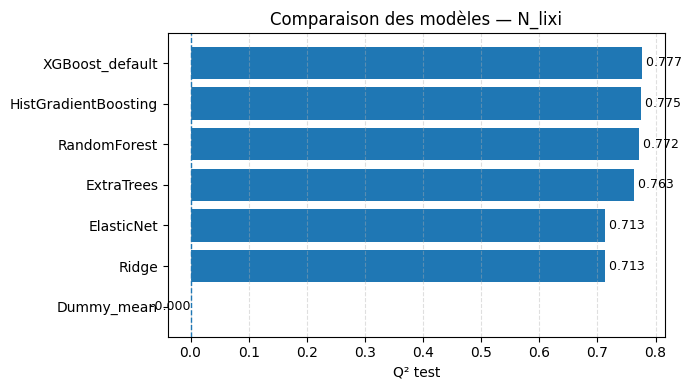

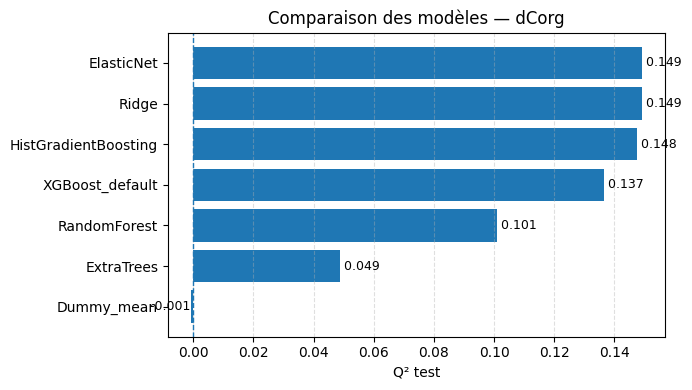

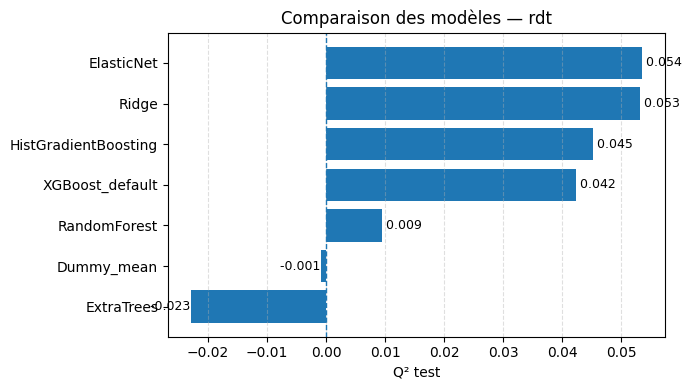

In [6]:
# ============================================================
# 6. Comparaison de modèles de référence
# ============================================================

models_to_compare = {
    "Dummy_mean": Pipeline([("preprocess", tree_preprocessor), ("model", DummyRegressor(strategy="mean"))]),
    "Ridge": Pipeline([("preprocess", linear_preprocessor), ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))]),
    "ElasticNet": Pipeline([("preprocess", linear_preprocessor), ("model", ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=10000, random_state=RANDOM_STATE))]),
    "RandomForest": Pipeline([("preprocess", tree_preprocessor), ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))]),
    "ExtraTrees": Pipeline([("preprocess", tree_preprocessor), ("model", ExtraTreesRegressor(n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1))]),
    "HistGradientBoosting": Pipeline([("preprocess", tree_preprocessor), ("model", HistGradientBoostingRegressor(max_iter=300, learning_rate=0.04, max_leaf_nodes=31, l2_regularization=0.1, random_state=RANDOM_STATE))]),
}

if HAS_XGBOOST:
    models_to_compare["XGBoost_default"] = Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", XGBRegressor(objective="reg:squarederror", n_estimators=600, max_depth=4, learning_rate=0.03, subsample=0.85, colsample_bytree=0.85, random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")),
    ])

comparison_rows = []
trained_reference_models = {}

for output in OUTPUT_COLS:
    train_data = df_train[FEATURES + [output]].dropna(subset=[output]).copy()
    test_data = df_test[FEATURES + [output]].dropna(subset=[output]).copy()
    X_train = train_data[FEATURES]
    y_train = train_data[output].values
    X_test = test_data[FEATURES]
    y_test = test_data[output].values
    print("\n" + "=" * 80)
    print("Sortie :", output)
    for model_name, model in models_to_compare.items():
        print("  Entraînement :", model_name)
        fitted = model.fit(X_train, y_train)
        scores = evaluate_model(fitted, X_train, y_train, X_test, y_test)
        comparison_rows.append({
            "sortie": output, "modele": model_name,
            "R2_train": scores["R2_train"], "Q2_test": scores["Q2_test"],
            "RMSE_train": scores["RMSE_train"], "RMSE_test": scores["RMSE_test"],
            "MAE_train": scores["MAE_train"], "MAE_test": scores["MAE_test"],
            "n_train": len(y_train), "n_test": len(y_test),
        })
        trained_reference_models[(output, model_name)] = fitted

comparison_df = pd.DataFrame(comparison_rows).sort_values(["sortie", "Q2_test"], ascending=[True, False])
print("\nRésumé comparatif :")
display(comparison_df)

for output in OUTPUT_COLS:
    sub = comparison_df[comparison_df["sortie"] == output].sort_values("Q2_test")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(sub["modele"], sub["Q2_test"])
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("Q² test")
    ax.set_title(f"Comparaison des modèles — {output}")
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    for i, v in enumerate(sub["Q2_test"]):
        ax.text(v, i, f" {v:.3f}", va="center", ha="left" if v >= 0 else "right", fontsize=9)
    plt.tight_layout()
    plt.show()


## 7. XGBoost régularisé avec recherche d'hyperparamètres


Optimisation XGBoost régularisé pour : N_lixi
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Meilleur score CV R² : 0.7835
R² entraînement      : 0.7916
Q² test              : 0.7791
RMSE train           : 3.3213
RMSE test            : 3.3788
MAE train            : 2.1464
MAE test             : 2.1863
Meilleurs paramètres :
  xgb__subsample: 0.9
  xgb__reg_lambda: 30.0
  xgb__reg_alpha: 0.1
  xgb__n_estimators: 800
  xgb__min_child_weight: 10
  xgb__max_depth: 3
  xgb__learning_rate: 0.01
  xgb__gamma: 1.0
  xgb__colsample_bytree: 0.8


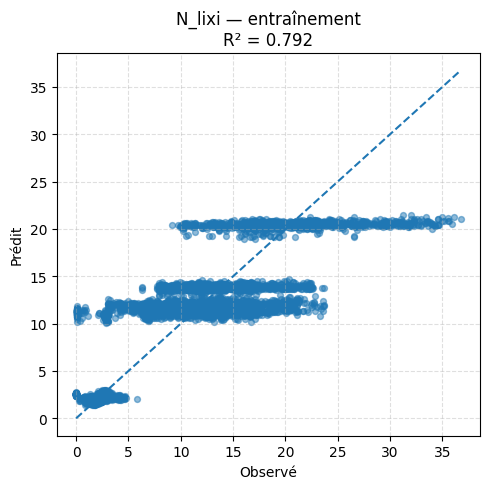

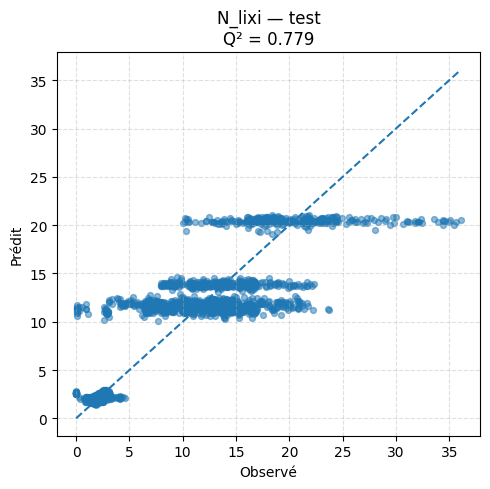


Optimisation XGBoost régularisé pour : dCorg
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Meilleur score CV R² : 0.1449
R² entraînement      : 0.1573
Q² test              : 0.1520
RMSE train           : 160.5010
RMSE test            : 161.3662
MAE train            : 139.5412
MAE test             : 140.5912
Meilleurs paramètres :
  xgb__subsample: 0.8
  xgb__reg_lambda: 3.0
  xgb__reg_alpha: 5.0
  xgb__n_estimators: 300
  xgb__min_child_weight: 5
  xgb__max_depth: 2
  xgb__learning_rate: 0.02
  xgb__gamma: 0.1
  xgb__colsample_bytree: 0.6


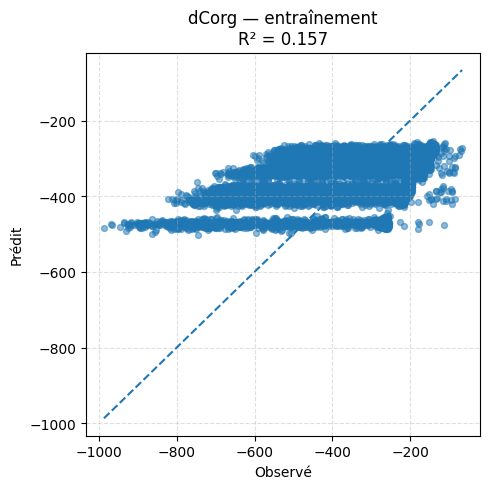

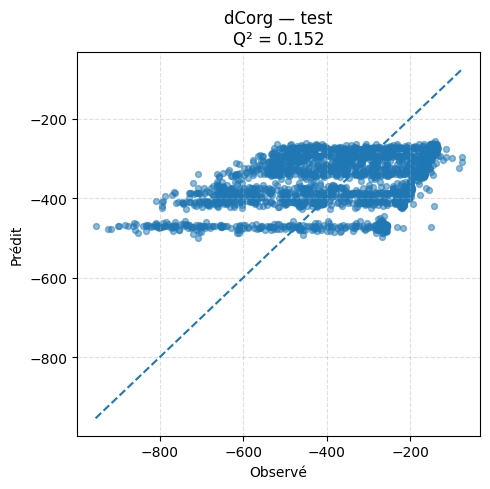


Optimisation XGBoost régularisé pour : rdt
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Meilleur score CV R² : 0.0587
R² entraînement      : 0.0776
Q² test              : 0.0549
RMSE train           : 1.3995
RMSE test            : 1.4290
MAE train            : 1.1303
MAE test             : 1.1557
Meilleurs paramètres :
  xgb__subsample: 0.9
  xgb__reg_lambda: 3.0
  xgb__reg_alpha: 1.0
  xgb__n_estimators: 300
  xgb__min_child_weight: 5
  xgb__max_depth: 3
  xgb__learning_rate: 0.01
  xgb__gamma: 0.1
  xgb__colsample_bytree: 0.7


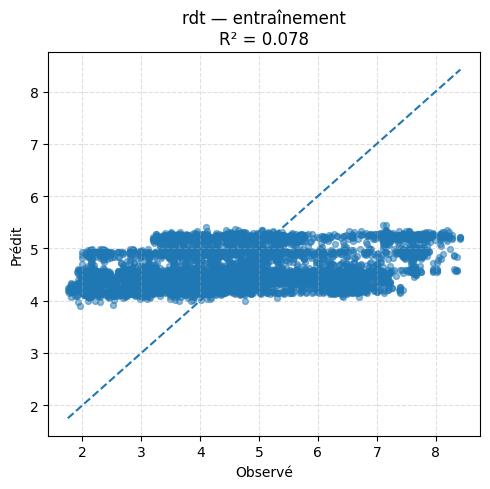

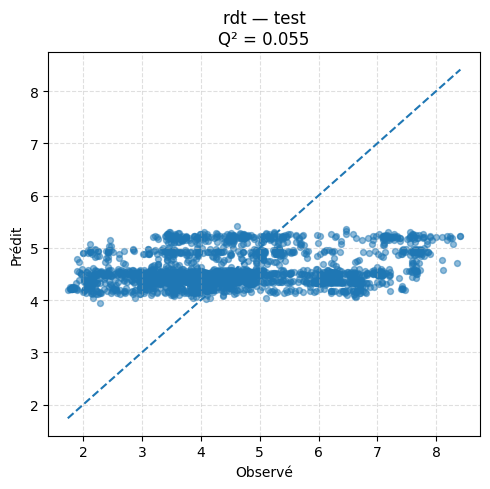


Résumé XGBoost régularisé :


,sortie,R2_train,Q2_test,CV_best_R2,RMSE_train,RMSE_test,MAE_train,MAE_test,n_train,n_test
0,N_lixi,0.791614,0.779099,0.783498,3.321322,3.378794,2.146366,2.186347,10400,2600
1,dCorg,0.157256,0.151964,0.144888,160.501007,161.366153,139.541224,140.591230,10400,2600
2,rdt,0.077571,0.054939,0.058747,1.399535,1.428970,1.130270,1.155672,10143,2529



Meilleurs hyperparamètres par sortie :

--------------------------------------------------------------------------------
N_lixi
xgb__subsample: 0.9
xgb__reg_lambda: 30.0
xgb__reg_alpha: 0.1
xgb__n_estimators: 800
xgb__min_child_weight: 10
xgb__max_depth: 3
xgb__learning_rate: 0.01
xgb__gamma: 1.0
xgb__colsample_bytree: 0.8

--------------------------------------------------------------------------------
dCorg
xgb__subsample: 0.8
xgb__reg_lambda: 3.0
xgb__reg_alpha: 5.0
xgb__n_estimators: 300
xgb__min_child_weight: 5
xgb__max_depth: 2
xgb__learning_rate: 0.02
xgb__gamma: 0.1
xgb__colsample_bytree: 0.6

--------------------------------------------------------------------------------
rdt
xgb__subsample: 0.9
xgb__reg_lambda: 3.0
xgb__reg_alpha: 1.0
xgb__n_estimators: 300
xgb__min_child_weight: 5
xgb__max_depth: 3
xgb__learning_rate: 0.01
xgb__gamma: 0.1
xgb__colsample_bytree: 0.7


In [7]:
# ============================================================
# 7. XGBoost régularisé avec RandomizedSearchCV groupé
# ============================================================

if not HAS_XGBOOST:
    raise ImportError("xgboost n'est pas installé. Installe-le avec : pip install xgboost")

xgb_pipeline = Pipeline([
    ("preprocess", tree_preprocessor),
    ("xgb", XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")),
])

param_distributions = {
    "xgb__n_estimators": [300, 500, 800, 1200],
    "xgb__max_depth": [2, 3, 4],
    "xgb__learning_rate": [0.01, 0.02, 0.03, 0.05],
    "xgb__min_child_weight": [1, 3, 5, 10, 20],
    "xgb__subsample": [0.6, 0.7, 0.8, 0.9],
    "xgb__colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "xgb__reg_alpha": [0.0, 0.01, 0.1, 1.0, 5.0],
    "xgb__reg_lambda": [1.0, 3.0, 10.0, 30.0, 100.0],
    "xgb__gamma": [0.0, 0.01, 0.1, 1.0],
}

N_ITER_SEARCH = 35
N_SPLITS_CV = 5
xgb_tuned_models = {}
xgb_tuned_rows = []

for output in OUTPUT_COLS:
    print("\n" + "=" * 90)
    print("Optimisation XGBoost régularisé pour :", output)
    train_data = df_train[FEATURES + [output, "point_idx"]].dropna(subset=[output]).copy()
    test_data = df_test[FEATURES + [output, "point_idx"]].dropna(subset=[output]).copy()
    X_train = train_data[FEATURES]
    y_train = train_data[output].values
    groups_train = train_data["point_idx"].values
    X_test = test_data[FEATURES]
    y_test = test_data[output].values
    n_groups_train = pd.Series(groups_train).nunique()
    n_splits = min(N_SPLITS_CV, n_groups_train)
    if n_splits < 2:
        raise RuntimeError("Pas assez de groupes pour la validation croisée groupée.")
    cv = GroupKFold(n_splits=n_splits)
    search = RandomizedSearchCV(
        estimator=xgb_pipeline, param_distributions=param_distributions,
        n_iter=N_ITER_SEARCH, scoring="r2", cv=cv, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=1, refit=True,
    )
    search.fit(X_train, y_train, groups=groups_train)
    best_model = search.best_estimator_
    scores = evaluate_model(best_model, X_train, y_train, X_test, y_test)
    xgb_tuned_models[output] = best_model
    xgb_tuned_rows.append({
        "sortie": output, "R2_train": scores["R2_train"], "Q2_test": scores["Q2_test"],
        "CV_best_R2": search.best_score_, "RMSE_train": scores["RMSE_train"], "RMSE_test": scores["RMSE_test"],
        "MAE_train": scores["MAE_train"], "MAE_test": scores["MAE_test"],
        "n_train": len(y_train), "n_test": len(y_test), "best_params": search.best_params_,
    })
    print(f"Meilleur score CV R² : {search.best_score_:.4f}")
    print(f"R² entraînement      : {scores['R2_train']:.4f}")
    print(f"Q² test              : {scores['Q2_test']:.4f}")
    print(f"RMSE train           : {scores['RMSE_train']:.4f}")
    print(f"RMSE test            : {scores['RMSE_test']:.4f}")
    print(f"MAE train            : {scores['MAE_train']:.4f}")
    print(f"MAE test             : {scores['MAE_test']:.4f}")
    print("Meilleurs paramètres :")
    for k, v in search.best_params_.items():
        print(f"  {k}: {v}")
    plot_observed_predicted(y_train, scores["y_train_pred"], f"{output} — entraînement", f"R² = {scores['R2_train']:.3f}")
    plot_observed_predicted(y_test, scores["y_test_pred"], f"{output} — test", f"Q² = {scores['Q2_test']:.3f}")

xgb_tuned_results_df = pd.DataFrame(xgb_tuned_rows)
print("\nRésumé XGBoost régularisé :")
display(xgb_tuned_results_df.drop(columns=["best_params"]))
print("\nMeilleurs hyperparamètres par sortie :")
for _, row in xgb_tuned_results_df.iterrows():
    print("\n" + "-" * 80)
    print(row["sortie"])
    for k, v in row["best_params"].items():
        print(f"{k}: {v}")


## 8. Variabilité séparée par sol et par climat

Cette partie ne combine pas le climat et le sol en une variable d'entrée. Elle sert seulement au diagnostic descriptif.

In [15]:
# ============================================================
# 8.1. Définition d'un espace Saltelli compatible avec df_model
# ============================================================

import numpy as np
import pandas as pd
import warnings
from pathlib import Path
from SALib.sample import saltelli
from SALib.analyze import sobol
from IPython.display import display

# ------------------------------------------------------------
# Vérifications minimales
# ------------------------------------------------------------

if "df_model" not in globals():
    raise RuntimeError(
        "df_model n'est pas défini. Exécute d'abord la cellule de chargement "
        "et de préparation du dataset métamodèle."
    )

# ------------------------------------------------------------
# Sorties disponibles
# ------------------------------------------------------------

outputs = ["N_lixi", "dCorg", "rdt"]
available_outputs = [out for out in outputs if out in df_model.columns]

if not available_outputs:
    raise RuntimeError("Aucune sortie disponible parmi : N_lixi, dCorg, rdt.")

# ------------------------------------------------------------
# Définition robuste des variables explicatives
# ------------------------------------------------------------
# On oublie volontairement la combinaison climat x sol.
# Les milieux sont conservés séparément : Milieu_Climat et Milieu_Sol.

candidate_numeric_features = [
    "n_ferti",
    "nb_prepa",
    "nb_f1",
    "nb_f2",
    "nb_f3",
    "Jour_Semis",
    "Jours_av_PREPA",
    "Jours_semis_F1",
    "Jours_F1_F2",
    "Jours_F2_F3",
    "Jours_op_recolte",
    "Dose_F1_1",
    "Dose_F1_2",
    "Dose_F2_1",
    "Dose_F2_2",
    "Dose_F3_1",
    "Dose_F3_2",
]

candidate_categorical_features = [
    "has_prepa",
    "prepa_1",
    "prepa_2",
    "type_f1_1",
    "type_f1_2",
    "type_f2_1",
    "type_f2_2",
    "type_f3_1",
    "type_f3_2",
    "Milieu_Climat",
    "Milieu_Sol",
]

# On garde seulement les colonnes réellement présentes dans df_model
numeric_features = [
    col for col in candidate_numeric_features
    if col in df_model.columns
]

categorical_features = [
    col for col in candidate_categorical_features
    if col in df_model.columns
]

features = numeric_features + categorical_features

if not features:
    raise RuntimeError(
        "Aucune variable explicative reconnue dans df_model. "
        "Vérifie les noms des colonnes."
    )

print("Sorties disponibles :", available_outputs)
print("Variables numériques :", numeric_features)
print("Variables catégorielles :", categorical_features)
print("Nombre total de variables explicatives :", len(features))

# ------------------------------------------------------------
# Construction de l'espace Sobol
# ------------------------------------------------------------
# Variables numériques : bornes min/max observées.
# Variables catégorielles : encodage entier 0 ... K-1, puis décodage en labels.

sobol_bounds = []
sobol_names = []
sobol_variable_types = {}
category_maps = {}

for col in numeric_features:
    values = df_model[col].dropna().astype(float)

    if len(values) == 0:
        print(f"Variable numérique ignorée car entièrement NaN : {col}")
        continue

    vmin = float(values.min())
    vmax = float(values.max())

    if np.isclose(vmin, vmax):
        print(f"Variable numérique ignorée car constante : {col}")
        continue

    sobol_names.append(col)
    sobol_bounds.append([vmin, vmax])
    sobol_variable_types[col] = "numeric"

for col in categorical_features:
    values = (
        df_model[col]
        .astype("object")
        .fillna("inactive")
        .astype(str)
    )

    cats = sorted(values.unique().tolist())

    if len(cats) < 2:
        print(f"Variable catégorielle ignorée car une seule modalité : {col}")
        continue

    category_maps[col] = cats

    sobol_names.append(col)
    sobol_bounds.append([0, len(cats) - 1])
    sobol_variable_types[col] = "categorical"

sobol_problem = {
    "num_vars": len(sobol_names),
    "names": sobol_names,
    "bounds": sobol_bounds,
}

features_sobol = sobol_problem["names"]

print("\nNombre de variables Sobol :", sobol_problem["num_vars"])

print("\nVariables Sobol :")
for name, bounds in zip(sobol_problem["names"], sobol_problem["bounds"]):
    print(f" - {name}: {bounds} ({sobol_variable_types[name]})")

print("\nModalités catégorielles :")
for col, cats in category_maps.items():
    print(f" - {col}: {cats}")

Sorties disponibles : ['N_lixi', 'dCorg', 'rdt']
Variables numériques : ['n_ferti', 'nb_prepa', 'nb_f1', 'nb_f2', 'nb_f3', 'Jour_Semis', 'Jours_av_PREPA', 'Jours_semis_F1', 'Jours_F1_F2', 'Jours_F2_F3', 'Jours_op_recolte', 'Dose_F1_1', 'Dose_F1_2', 'Dose_F2_1', 'Dose_F2_2', 'Dose_F3_1', 'Dose_F3_2']
Variables catégorielles : ['has_prepa', 'prepa_1', 'prepa_2', 'type_f1_1', 'type_f1_2', 'type_f2_1', 'type_f2_2', 'type_f3_1', 'type_f3_2', 'Milieu_Climat', 'Milieu_Sol']
Nombre total de variables explicatives : 28

Nombre de variables Sobol : 28

Variables Sobol :
 - n_ferti: [0.0, 3.0] (numeric)
 - nb_prepa: [0.0, 1.0] (numeric)
 - nb_f1: [0.0, 3.0] (numeric)
 - nb_f2: [0.0, 1.0] (numeric)
 - nb_f3: [0.0, 3.0] (numeric)
 - Jour_Semis: [260.0071638879149, 319.98942173036454] (numeric)
 - Jours_av_PREPA: [1.0020982664337104, 29.99729710317295] (numeric)
 - Jours_semis_F1: [100.0013005422842, 249.9957337039335] (numeric)
 - Jours_F1_F2: [1.004056390276452, 59.996910775195] (numeric)
 - Jours

/var/folders/3w/jkcxrcp52l38n06g8rzw0mqc0000gn/T/ipykernel_54542/3040890616.py:130: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna("inactive")
/var/folders/3w/jkcxrcp52l38n06g8rzw0mqc0000gn/T/ipykernel_54542/3040890616.py:130: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna("inactive")
/var/folders/3w/jkcxrcp52l38n06g8rzw0mqc0000gn/T/ipykernel_54542/3040890616.py:130: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To o

Modèles utilisés : xgb_tuned_models
X_saltelli_raw absent : génération d'un nouveau plan Saltelli.
N_SALTELLI = 1024
D = 28
calc_second_order = False
Nombre de lignes attendu = 30720
Plan Saltelli généré : (30720, 28)

Plan Saltelli décodé :


,n_ferti,nb_prepa,nb_f1,nb_f2,nb_f3,Jour_Semis,Jours_av_PREPA,Jours_semis_F1,Jours_F1_F2,Jours_F2_F3,...,prepa_1,prepa_2,type_f1_1,type_f1_2,type_f2_1,type_f2_2,type_f3_1,type_f3_2,Milieu_Climat,Milieu_Sol
0,0.004395,0.376465,1.343262,0.486816,1.671387,310.646482,8.010215,188.108382,42.108941,40.618109,...,2.0,0.0,1.0,0.0,2.0,2.0,2.0,1.0,sudouest,limono-sableux
1,0.944824,0.376465,1.343262,0.486816,1.671387,310.646482,8.010215,188.108382,42.108941,40.618109,...,2.0,0.0,1.0,0.0,2.0,2.0,2.0,1.0,sudouest,limono-sableux
2,0.004395,0.043457,1.343262,0.486816,1.671387,310.646482,8.010215,188.108382,42.108941,40.618109,...,2.0,0.0,1.0,0.0,2.0,2.0,2.0,1.0,sudouest,limono-sableux
3,0.004395,0.376465,2.983887,0.486816,1.671387,310.646482,8.010215,188.108382,42.108941,40.618109,...,2.0,0.0,1.0,0.0,2.0,2.0,2.0,1.0,sudouest,limono-sableux
4,0.004395,0.376465,1.343262,0.966309,1.671387,310.646482,8.010215,188.108382,42.108941,40.618109,...,2.0,0.0,1.0,0.0,2.0,2.0,2.0,1.0,sudouest,limono-sableux



Features utilisées pour la prédiction :
['n_ferti', 'nb_prepa', 'nb_f1', 'nb_f2', 'nb_f3', 'Jour_Semis', 'Jours_av_PREPA', 'Jours_semis_F1', 'Jours_F1_F2', 'Jours_F2_F3', 'Jours_op_recolte', 'Dose_F1_1', 'Dose_F1_2', 'Dose_F2_1', 'Dose_F2_2', 'Dose_F3_1', 'Dose_F3_2', 'has_prepa', 'prepa_1', 'prepa_2', 'type_f1_1', 'type_f1_2', 'type_f2_1', 'type_f2_2', 'type_f3_1', 'type_f3_2', 'Milieu_Climat', 'Milieu_Sol']

Calcul Sobol ST pour : N_lixi

Calcul Sobol ST pour : dCorg

Calcul Sobol ST pour : rdt

Indices de Sobol d'ordre total ST :


,sortie,parametre,ST,ST_conf,S1,S1_conf
0,N_lixi,Milieu_Climat,0.954940,0.070324,0.867657,0.073798
1,N_lixi,Milieu_Sol,0.131049,0.023574,0.044465,0.028372
2,N_lixi,Dose_F1_2,0.000842,0.000115,0.000317,0.002419
3,N_lixi,Dose_F2_2,0.000612,0.000127,0.001367,0.002213
4,N_lixi,Dose_F1_1,0.000361,0.000066,0.000528,0.001879
...,...,...,...,...,...,...
79,rdt,type_f1_2,0.000000,0.000000,0.000000,0.000000
80,rdt,type_f2_1,0.000000,0.000000,0.000000,0.000000
81,rdt,type_f2_2,0.000000,0.000000,0.000000,0.000000
82,rdt,type_f3_1,0.000000,0.000000,0.000000,0.000000


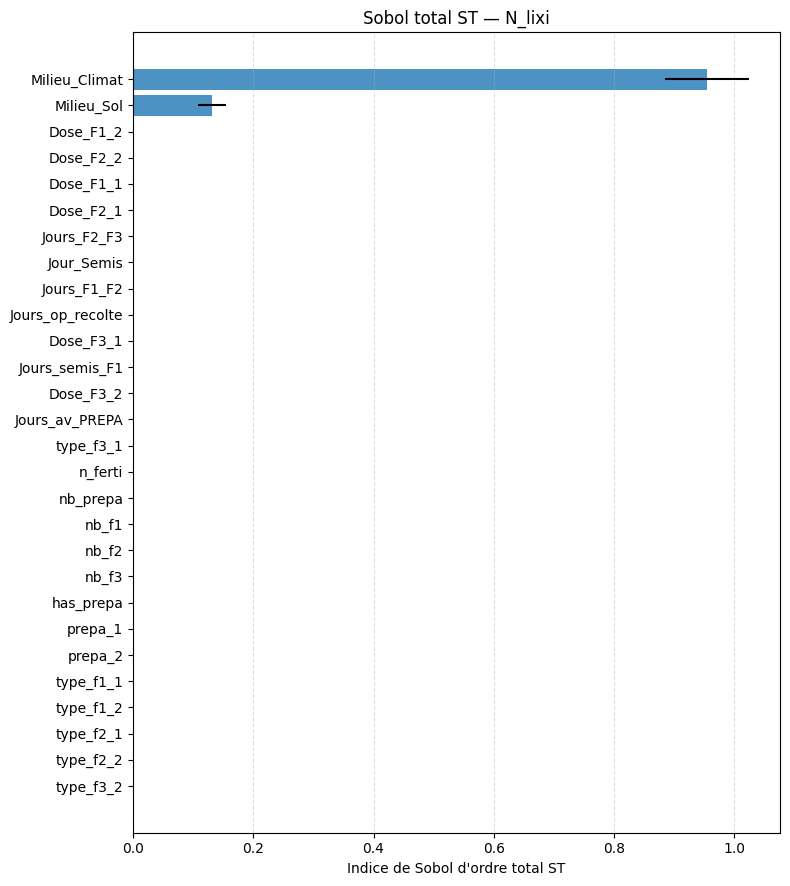

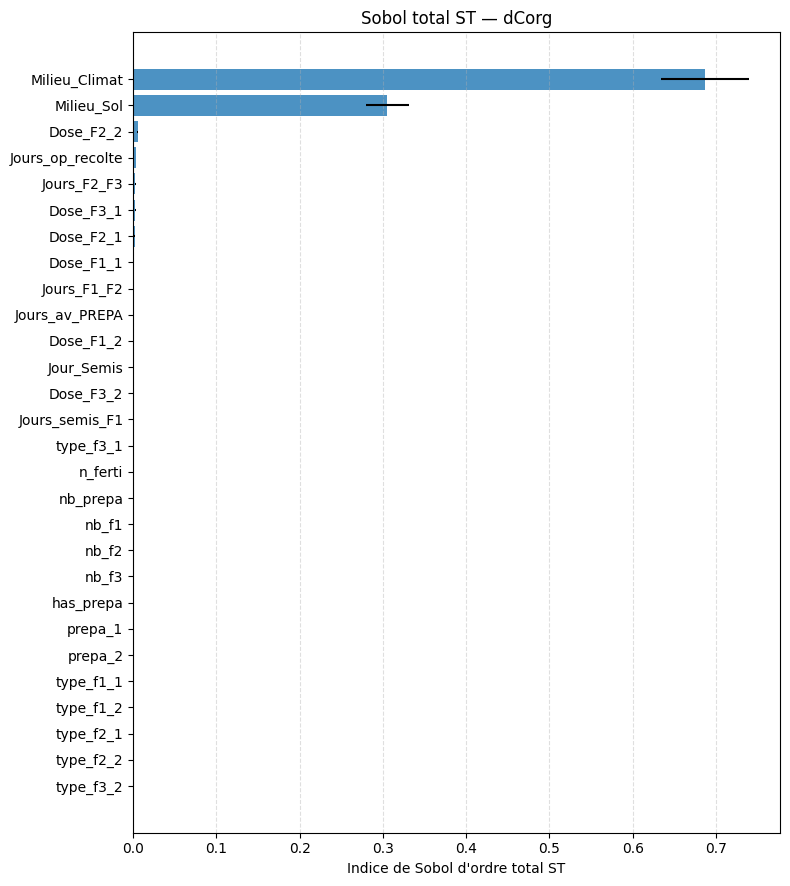

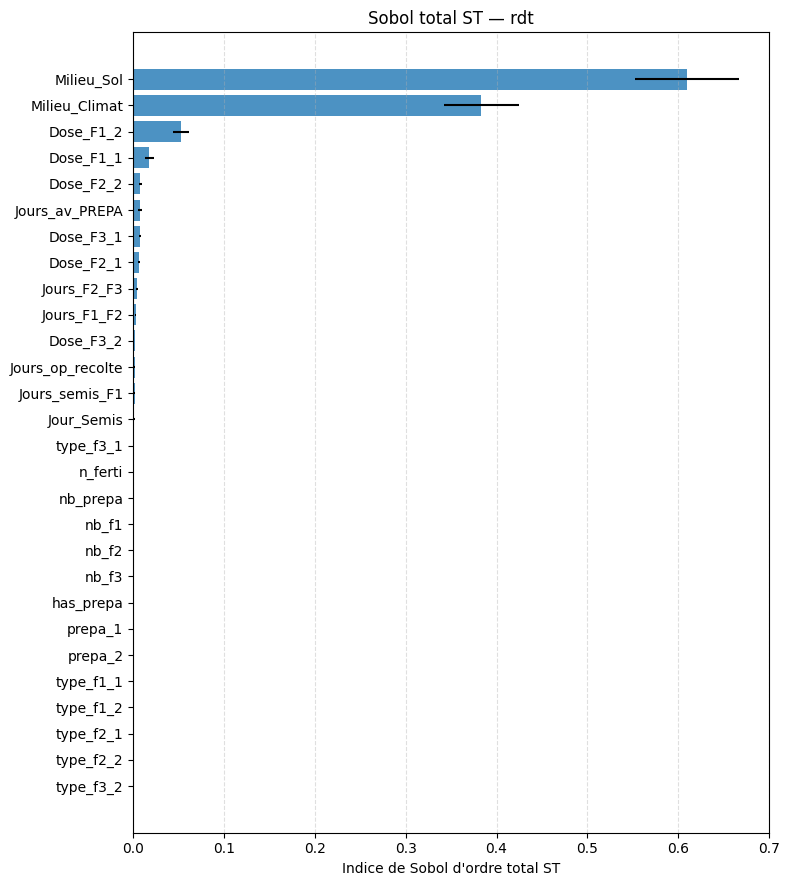

In [19]:
# ============================================================
# 8.3. Génération Saltelli si nécessaire + indices Sobol totaux ST
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from SALib.sample import saltelli
from SALib.analyze import sobol
from IPython.display import display

# ------------------------------------------------------------
# 1. Vérifications et récupération des modèles
# ------------------------------------------------------------

if "df_model" not in globals():
    raise RuntimeError("df_model est absent. Exécute d'abord la préparation du dataset.")

if "sobol_problem" not in globals():
    raise RuntimeError("sobol_problem est absent. Exécute d'abord la cellule 8.1.")

if "sobol_variable_types" not in globals():
    raise RuntimeError("sobol_variable_types est absent. Exécute d'abord la cellule 8.1.")

if "category_maps" not in globals():
    raise RuntimeError("category_maps est absent. Exécute d'abord la cellule 8.1.")

if "available_outputs" not in globals():
    available_outputs = [c for c in ["N_lixi", "dCorg", "rdt"] if c in df_model.columns]

if "CALC_SECOND_ORDER" not in globals():
    CALC_SECOND_ORDER = False

if "N_SALTELLI" not in globals():
    N_SALTELLI = 1024

sobol_models = {}

if "xgb_tuned_models" in globals() and isinstance(xgb_tuned_models, dict) and len(xgb_tuned_models) > 0:
    sobol_models = xgb_tuned_models
    print("Modèles utilisés : xgb_tuned_models")

elif "models" in globals() and isinstance(models, dict) and len(models) > 0:
    sobol_models = models
    print("Modèles utilisés : models")

elif "trained_models" in globals() and isinstance(trained_models, dict) and len(trained_models) > 0:
    for output in available_outputs:
        if output in trained_models:
            sobol_models[output] = trained_models[output]

    if not sobol_models:
        for output in available_outputs:
            key = (output, "XGBoost")
            if key in trained_models:
                sobol_models[output] = trained_models[key]

    if sobol_models:
        print("Modèles utilisés : trained_models")

if not sobol_models:
    raise RuntimeError(
        "Aucun modèle entraîné trouvé. Exécute d'abord la cellule d'entraînement XGBoost."
    )

# ------------------------------------------------------------
# 2. Génération du plan Saltelli si absent
# ------------------------------------------------------------

if "X_saltelli_raw" not in globals():
    print("X_saltelli_raw absent : génération d'un nouveau plan Saltelli.")

    D = sobol_problem["num_vars"]
    expected_runs = N_SALTELLI * (2 * D + 2) if CALC_SECOND_ORDER else N_SALTELLI * (D + 2)

    print(f"N_SALTELLI = {N_SALTELLI}")
    print(f"D = {D}")
    print(f"calc_second_order = {CALC_SECOND_ORDER}")
    print(f"Nombre de lignes attendu = {expected_runs}")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        X_saltelli_raw = saltelli.sample(
            sobol_problem,
            N_SALTELLI,
            calc_second_order=CALC_SECOND_ORDER,
        )

    print("Plan Saltelli généré :", X_saltelli_raw.shape)

else:
    print("Plan Saltelli existant trouvé :", X_saltelli_raw.shape)

# ------------------------------------------------------------
# 3. Décodage du plan Saltelli vers DataFrame compatible modèle
# ------------------------------------------------------------

def decode_saltelli_to_dataframe(X_raw, problem, variable_types, category_maps):
    df_sobol = pd.DataFrame(X_raw, columns=problem["names"])

    for col in problem["names"]:
        if variable_types[col] == "categorical":
            cats = category_maps[col]
            idx = np.rint(df_sobol[col].values).astype(int)
            idx = np.clip(idx, 0, len(cats) - 1)
            df_sobol[col] = [cats[i] for i in idx]
        else:
            df_sobol[col] = df_sobol[col].astype(float)

    return df_sobol

X_sobol_df = decode_saltelli_to_dataframe(
    X_saltelli_raw,
    sobol_problem,
    sobol_variable_types,
    category_maps,
)

print("\nPlan Saltelli décodé :")
display(X_sobol_df.head())

# ------------------------------------------------------------
# 4. Features attendues par les modèles
# ------------------------------------------------------------

if "features" in globals():
    model_features = [f for f in features if f != "Milieu_Climat_x_Sol"]
else:
    model_features = list(sobol_problem["names"])

model_features = list(dict.fromkeys(model_features))

print("\nFeatures utilisées pour la prédiction :")
print(model_features)

# ------------------------------------------------------------
# 5. Prédiction et calcul Sobol ST
# ------------------------------------------------------------

sobol_total_rows = []
sobol_predictions = {}

for output in available_outputs:
    if output not in sobol_models:
        print(f"Pas de modèle disponible pour {output}, sortie ignorée.")
        continue

    print("\n" + "=" * 80)
    print(f"Calcul Sobol ST pour : {output}")

    model = sobol_models[output]

    X_for_model = X_sobol_df.copy()

    for col in model_features:
        if col not in X_for_model.columns:
            if "categorical_features" in globals() and col in categorical_features:
                X_for_model[col] = "inactive"
            else:
                X_for_model[col] = np.nan

    X_for_model = X_for_model[model_features]

    y_pred = model.predict(X_for_model)

    if not np.all(np.isfinite(y_pred)):
        raise RuntimeError(f"Prédictions non finies pour {output}.")

    sobol_predictions[output] = y_pred

    Si = sobol.analyze(
        sobol_problem,
        y_pred,
        calc_second_order=CALC_SECOND_ORDER,
        print_to_console=False,
    )

    for name, st, st_conf, s1, s1_conf in zip(
        sobol_problem["names"],
        Si["ST"],
        Si["ST_conf"],
        Si["S1"],
        Si["S1_conf"],
    ):
        sobol_total_rows.append({
            "sortie": output,
            "parametre": name,
            "ST": st,
            "ST_conf": st_conf,
            "S1": s1,
            "S1_conf": s1_conf,
        })

sobol_total_df = pd.DataFrame(sobol_total_rows)

if sobol_total_df.empty:
    raise RuntimeError("Aucun indice Sobol n'a été calculé.")

sobol_total_df = sobol_total_df.sort_values(
    ["sortie", "ST"],
    ascending=[True, False],
).reset_index(drop=True)

print("\nIndices de Sobol d'ordre total ST :")
display(sobol_total_df)

# ------------------------------------------------------------
# 6. Graphiques ST
# ------------------------------------------------------------

for output in sobol_total_df["sortie"].unique():
    sub = sobol_total_df[sobol_total_df["sortie"] == output].copy()
    sub = sub.sort_values("ST", ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(5, 0.32 * len(sub))))

    ax.barh(
        sub["parametre"],
        sub["ST"],
        xerr=sub["ST_conf"],
        alpha=0.8,
    )

    ax.set_xlabel("Indice de Sobol d'ordre total ST")
    ax.set_title(f"Sobol total ST — {output}")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()